# Compare Function

This notebook shows an example use of the fit_compare function, designed to incorporate and apply the functions previously designed and listed in the Decomp and TFP example notebooks. For further detail on the operation of individual functions, please refer to those notebooks.

In [3]:
# Importing needed dependencies
import os
import numpy as np
import matplotlib.pyplot as plt
import hyperspy.api as hs
from scipy import optimize

# Importing relevant sections of the repository
import ACPP_Bunjy.tfp as tfp
import ACPP_Bunjy.decomp as decomp
import ACPP_Bunjy.compare as compare

## Data Formatting

Before using the fit_compare function, it is necessary to correctly load and format the data being worked on for handling by the function. The auto_import function from the ACPP_Bunjy.decomp module has been designed for this purpose. For full details of the function, see Decomp_examples in the Example Notebooks folder.

The example data being used for this section is a cropped section of the electron lattice dataset that has been worked on over the course of my project.

In [1]:
# Example dataset and desired crop
fn = '/014_lsmo_lfo_sto_interface_domain_wall_long_side_holz_fast_PT1D.npy'
crop = (slice(0,25),slice(0,25),slice(None))

# Loading dataset
data_ex = decomp.auto_import(fn,crop=crop)

WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)
WARNING | Hyperspy | Numba is not installed, falling back to non-accelerated implementation. (hyperspy.decorators:256)


## Fit Compare

The fit compare function has been designed to effectively carry out the majority of the project work in a singular function. It combines the decomposition process with the periodic signal fitting, on both the raw and cleaned datasets and then compares the quality of cleanup by various means, including examination of metrics and residual plots of fitted parameters and errors. The various toggles for data returns of the sub-functions applied are present in the function, with explanations to each seen below. Additionally, the function has the ability to save a processed dataset as a dict object for later processing without having to run the full function again, a useful ability for working with larger datasets. The full list of inputs and putputs of the function is found below:

    Required Parameters
    -------------------
    dataset: hs.signals.Signal1D
        Imported and processed dataset, optimally the output of decomp.auto_import.
    vectors: int
        The number of desried vector components for reconstruction after the decomposition.
    params_guess: list
        Initial guess values for the TFP fitted parameters.
    bounds: list or array
        Paired arrays defining the lower and upper bounds of possible parameters respectively.

    Optional Parameters
    -------------------
    algorithm: str
        Algorithm for use by Hyperspy decomposition, see Hyperspy documentation.
    metrics: bool, optional
        Toggle to return decomposition goodness metrics.
    component_plots: bool, optional
        Toggle to plot an example set of averaged vector components for visualisation.
    param_plots: bool, optional
        Toggle to plot heatmaps of each found fitted parameter
    residuals: bool, optional
        Toggle to plot residual plots of the parameter heatmaps.
    iterative_fitting: bool, optional
        Toggle for iterative parameter guessing in perfit_iterate, enabled as default.
    clean_outliers: bool, optional
        Toggle to clean outlying data points from error data.
    save_data: bool, optional
        Toggle to save results of the function, useful for big datasets.
    filename: str
        Filename under which to save dataset if save_data=True.

    Returns
    -------
    full_data: dict
        Compiled results of all sub-functions, containing data, parameters, parameter errors, and R^2 array,
        for both raw and clean data, and goodness metrics into a dict object with corresponding tags for each, 
        e.g. full_data["Raw"]["R2"] would return the raw R2 array. This is compatible with np.save providing 
        that the data is loaded with allow_pickle=True in np.load, and as data.item().get("Raw","R2").

Decomposition info:
  normalize_poissonian_noise=False
  algorithm=SVD
  output_dimension=None
  centre=None
Relative reconstruction error: 0.15773532107737706
Explained variance ratio: 0.9751195684846167
Noise suppression metric: 0.6819317729407025


Fitting periodic functions: 100%|██████████| 625/625 [00:03<00:00, 158.23it/s]


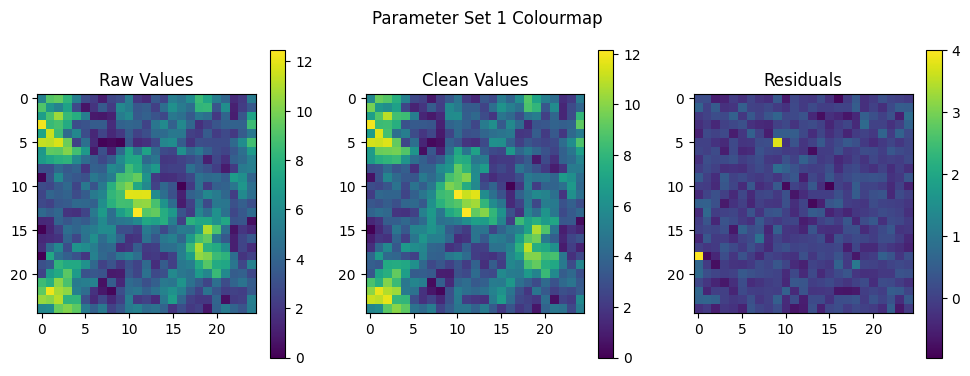

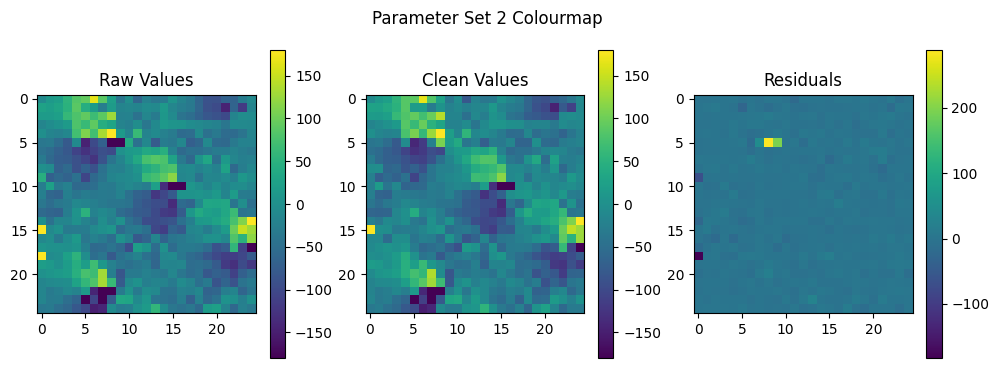

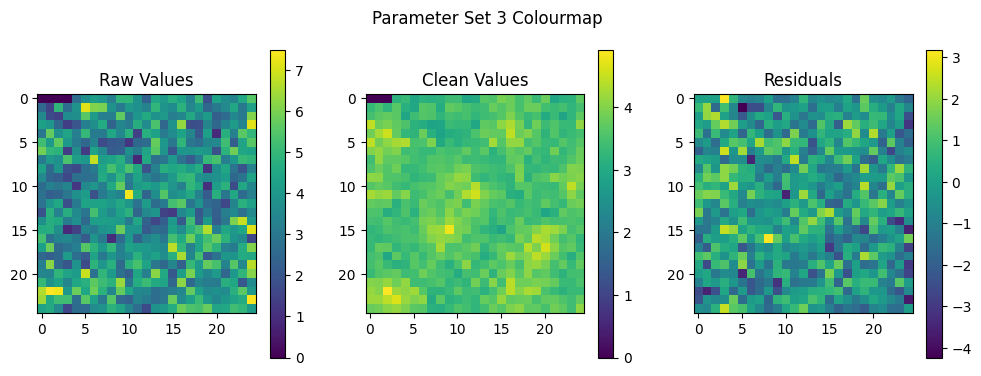

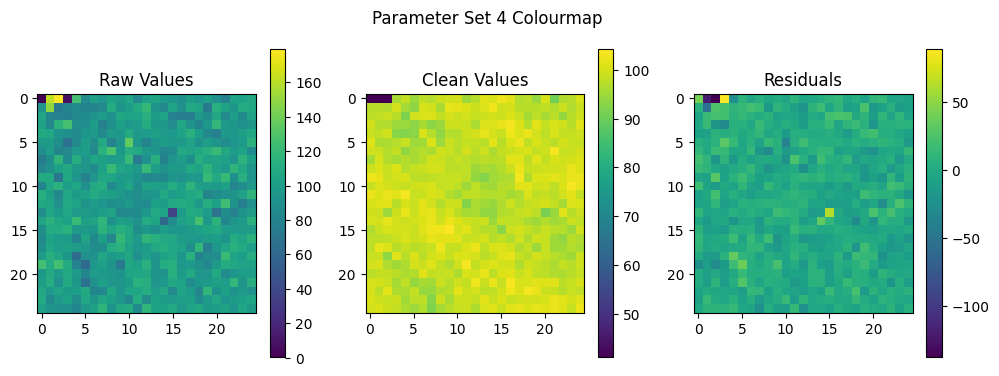

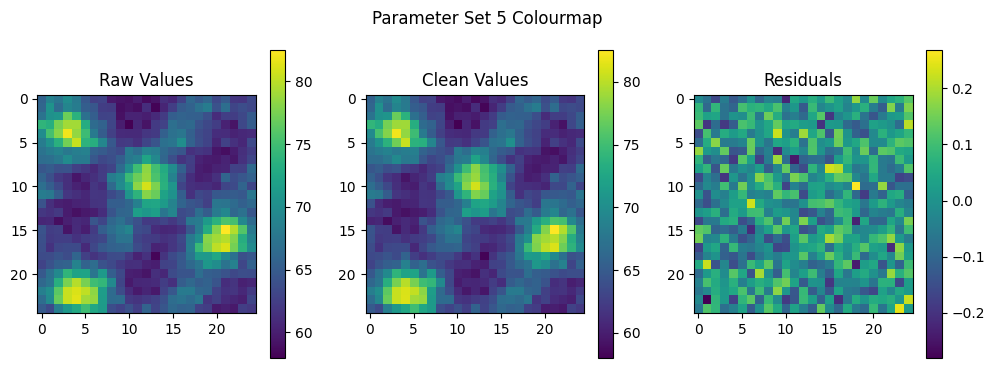

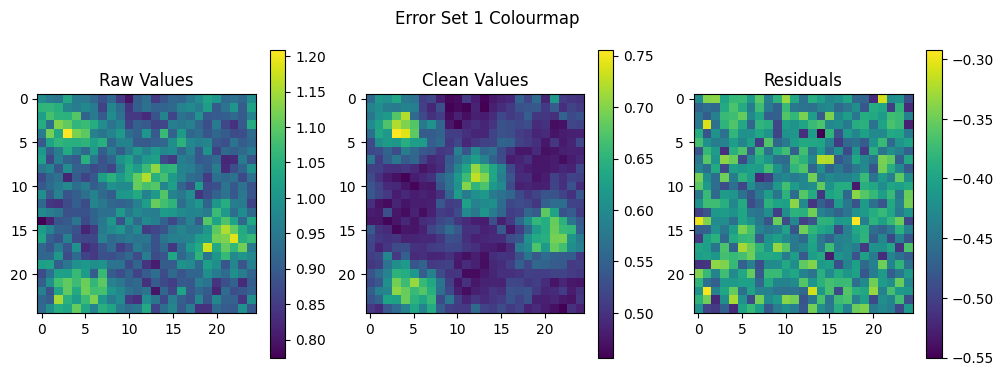

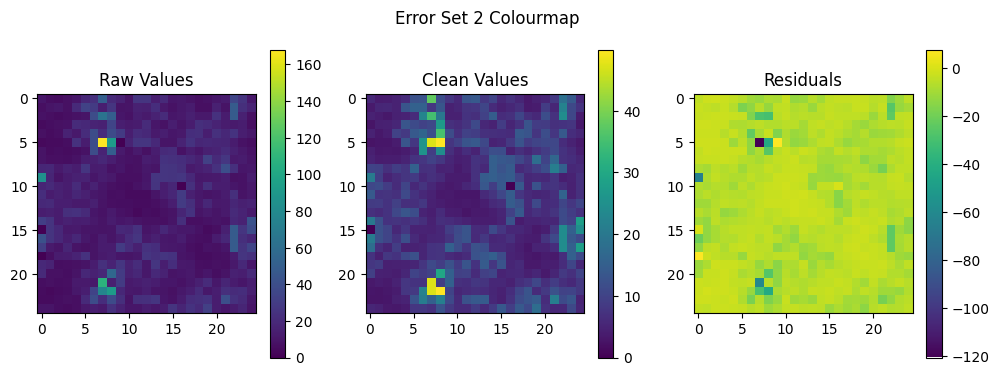

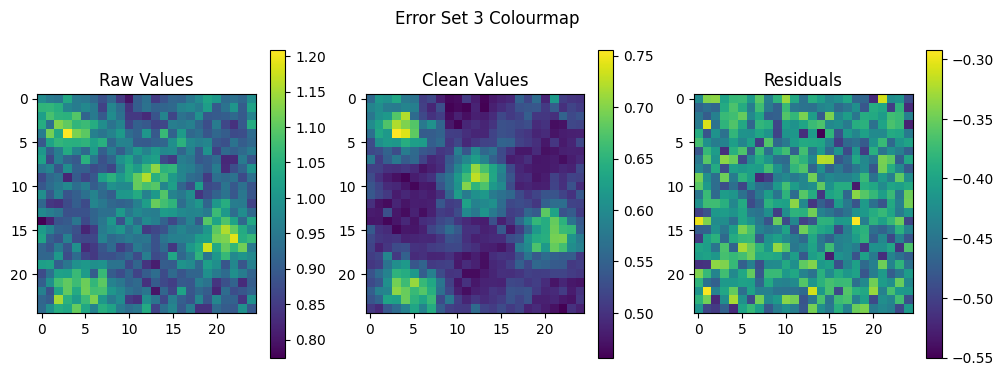

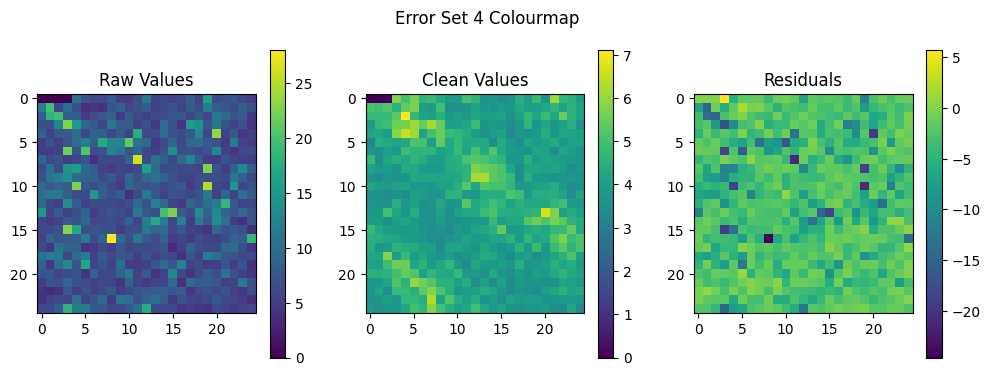

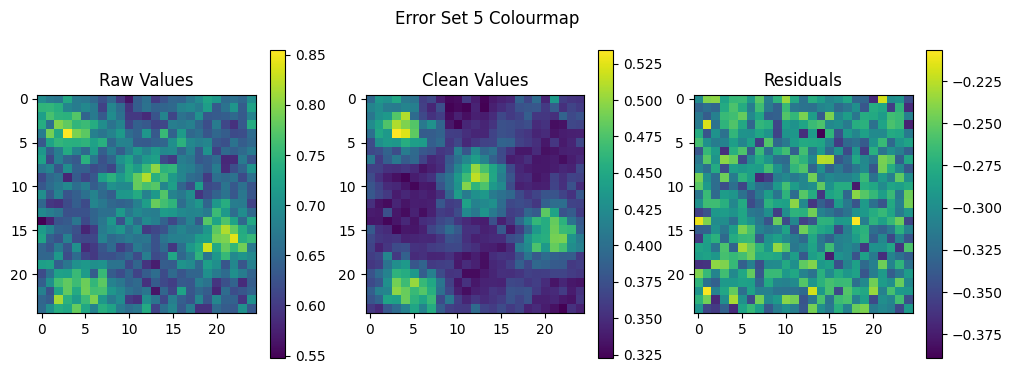

In [5]:
# Setting example input parameters to the function
vectors = 4
params_guess = [0,0,0,0,0]
bounds = (
    [0,-180,0,0,0],
    [np.inf,180,np.inf,180,np.inf]
)

# Running fit_compare, returning all optional args to show full process of the function
test = compare.fit_compare(data_ex, vectors, params_guess, bounds=bounds, metrics=True, param_plots=True, residuals=True, clean_outliers=True, save_data=True, filename='savetest2')

## Saved Data

Finally, to demonstrate that the saved data can be loaded in and accessed effectively, see below the process of realoading data. As the data is saved in the form of a dict object, desired components can be returned by accessing the names in the .get() function. For instance:

    save_test.item().get("Clean","Data")

Would return the cleaned dataset produced by the fit_compare function.

In [6]:
# Reloading the data with numpy np.load
save_test = np.load('savetest2.npy', allow_pickle=True)

# Returning the metrics of goodness from the dataset as an example
save_test.item().get("Metrics")

[0.15773532107737706, 0.9751195684846167, 0.6819317729407025]